In [251]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import UnivariateSpline
from win_prob import *
import numpy as np
import seaborn as sns
sns.set_theme(context='paper', style='darkgrid', palette='bright')


In [2]:
df = pd.read_csv("Wimbledon_featured_matches.csv")


sets = df["p1_sets"].astype(str) + "-" + df["p2_sets"].astype(str)
games = df["p1_games"].astype(str) + "-" + df["p2_games"].astype(str)
points = df["p1_score"].astype(str) + "-" + df["p2_score"].astype(str)
server = df["server"]
p = 0.655161325 
met = Metric_Finder(p)
df["win_prob"] = list(map(lambda x,y,z: win_prob(x,y,z), sets, games, points))
df["aheadness"] = list(map(lambda x,y,z,a: met.find_metric(x, y, z, a), sets, games, points, server))

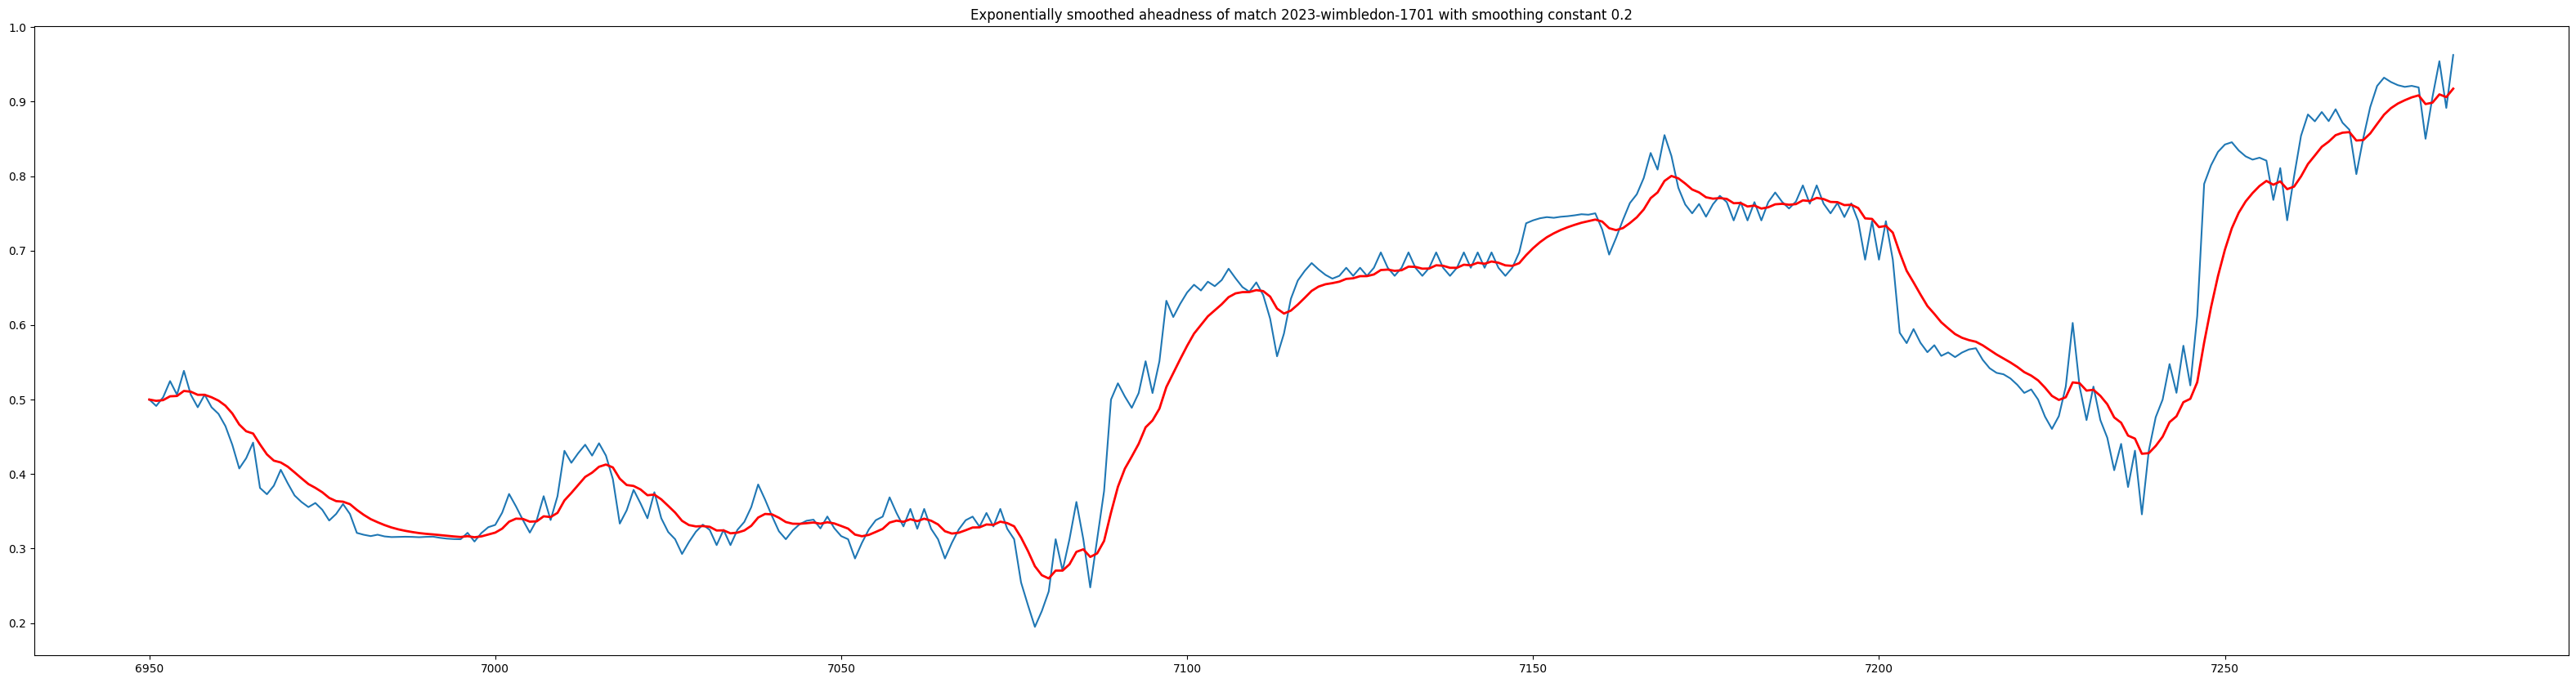

In [3]:
test_match_id = '2023-wimbledon-1701'
test_match = df[df['match_id'] == test_match_id]
alpha = 0.2 # smoothing factor
df['simple_exp_smoothed_aheadness'] = 0.0
for i in range(len(df)):
    if df.loc[i, 'point_no'] == 1:
        df.loc[i, 'simple_exp_smoothed_aheadness'] = df.loc[i, "aheadness"]
    else:
        df.loc[i, 'simple_exp_smoothed_aheadness'] = alpha*df.loc[i, 'aheadness'] + (1 - alpha) * df.loc[i-1, 'simple_exp_smoothed_aheadness']

df['exp_error'] = 0.0
for i in range(len(df)):
    if df.loc[i, 'point_no'] == 1:
        df.loc[i, 'exp_error'] = 0
    else:
        df.loc[i, 'exp_error'] = df.loc[i, 'aheadness'] - df.loc[i, 'simple_exp_smoothed_aheadness']


plt.figure(figsize=(40,10))
plt.plot(df[df['match_id'] == test_match_id]['aheadness'])
plt.plot(df[df['match_id'] == test_match_id]['simple_exp_smoothed_aheadness'], 'r', lw=2)
plt.title("Exponentially smoothed aheadness of match " + str(test_match_id) + " with smoothing constant " + str(alpha))
plt.show()

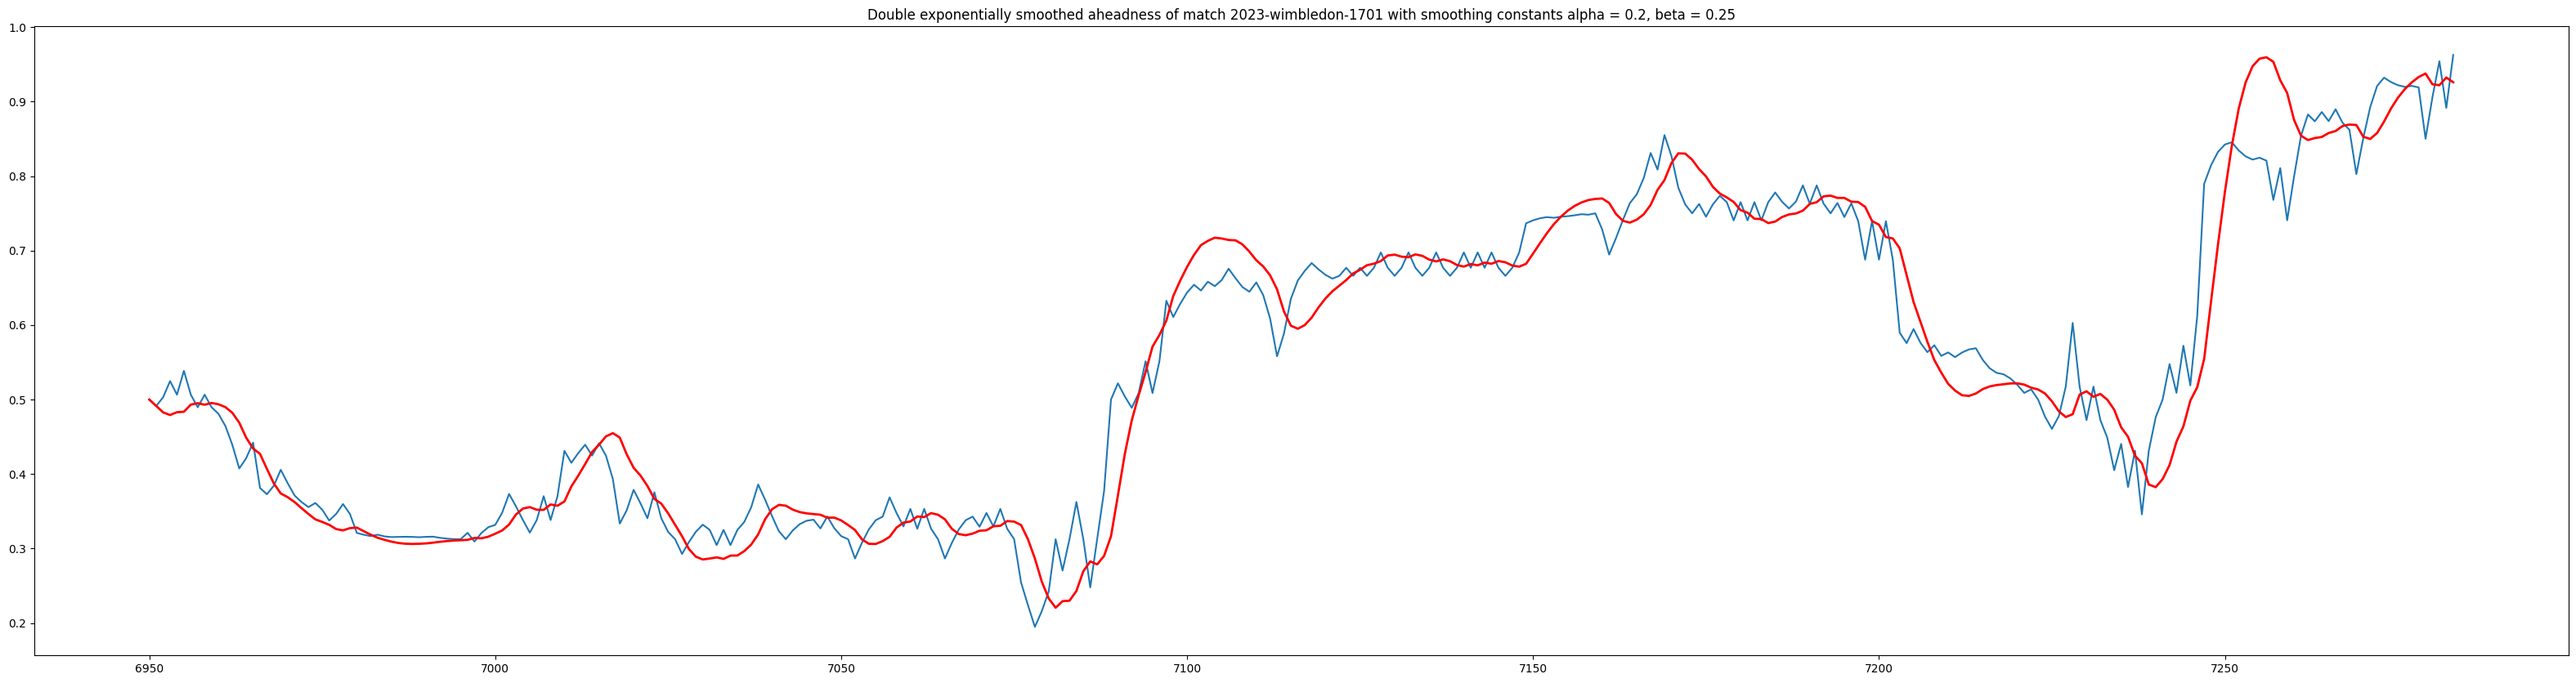

In [4]:
alpha = 0.2 # data smoothing factor 
beta = 0.25 # trend smoothing factor
df['double_exp_smoothed_aheadness'] = 0.0
s_t = [0.0]*len(df)
b_t = [0.0]*len(df)
for i in range(len(df)):
    if df.loc[i, 'point_no'] == 1:
        s_t[i] = df.loc[i, "aheadness"]
        b_t[i] = df.loc[i + 1, "aheadness"] - df.loc[i, "aheadness"]
        df.loc[i, 'double_exp_smoothed_aheadness'] = df.loc[i, "aheadness"]
    else:
        s_t[i] = alpha * df.loc[i, "aheadness"] + (1 - alpha) * (s_t[i-1] + b_t[i-1])
        b_t[i] = beta * (s_t[i] - s_t[i-1]) + (1 - beta) * b_t[i-1]
        df.loc[i, 'double_exp_smoothed_aheadness'] = s_t[i-1] + b_t[i-1]

plt.figure(figsize=(40,10))
plt.plot(df[df['match_id'] == test_match_id]['aheadness'])
plt.plot(df[df['match_id'] == test_match_id]['double_exp_smoothed_aheadness'], 'r', lw=2)
plt.title("Double exponentially smoothed aheadness of match " + str(test_match_id) + " with smoothing constants alpha = " + str(alpha) + ", beta = " + str(beta))
plt.show()

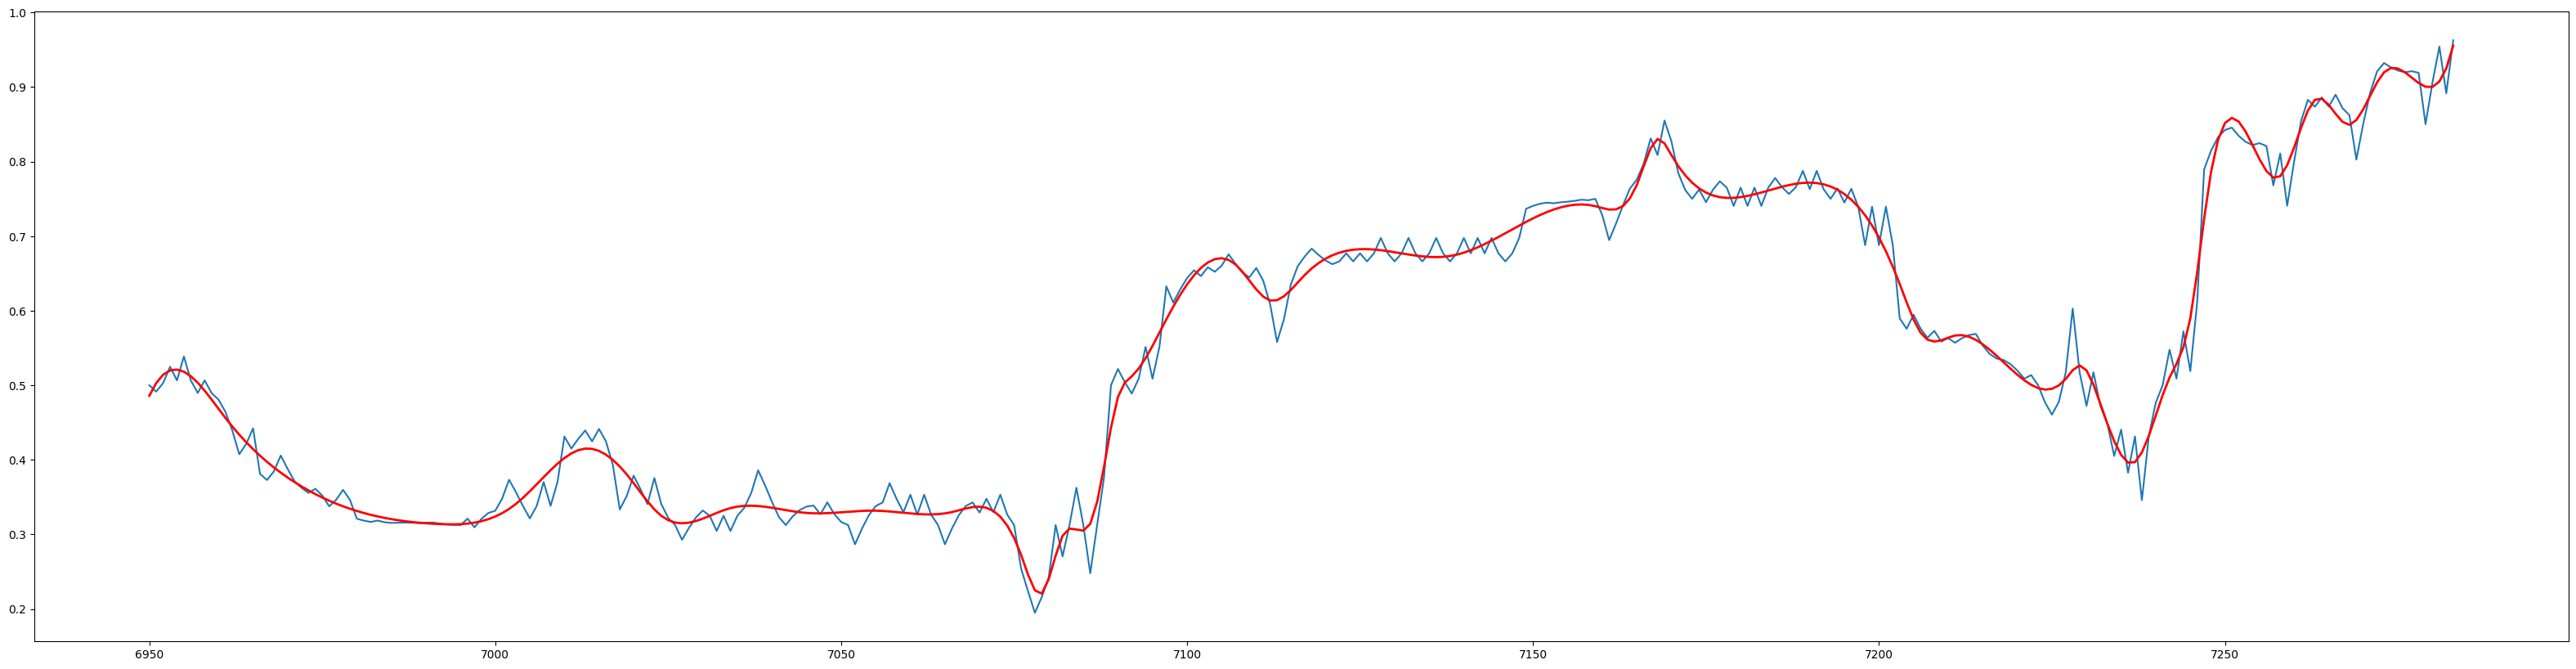

In [5]:
ans = []
for name, group in df.groupby(['match_id']):
    y = group['aheadness']
    x = range(len(y))
    spl = UnivariateSpline(x, y)
    spl.set_smoothing_factor(0.15)
    #print(list(spl(x)))
    ans = np.append(ans, list(spl(x)))
#print(ans)
df["smooth_ahead"] = ans

df['past_aided_aheadness'] = 0.0
for i in range(len(df)):
    if df.loc[i, 'point_no'] == 1 or df.loc[i, 'point_no'] == 2:
        df.loc[i, 'past_aided_aheadness'] = df.loc[i, 'aheadness']
    else:
        df.loc[i, 'past_aided_aheadness'] = (df.loc[i, 'aheadness'] + df.loc[i-1, 'aheadness'] + df.loc[i-2, 'aheadness'])/3.0


plt.figure(figsize=(40,10))
plt.plot(df[df['match_id'] == '2023-wimbledon-1701']['aheadness'])
plt.plot(df[df['match_id'] == '2023-wimbledon-1701']['smooth_ahead'], 'r', lw=2)

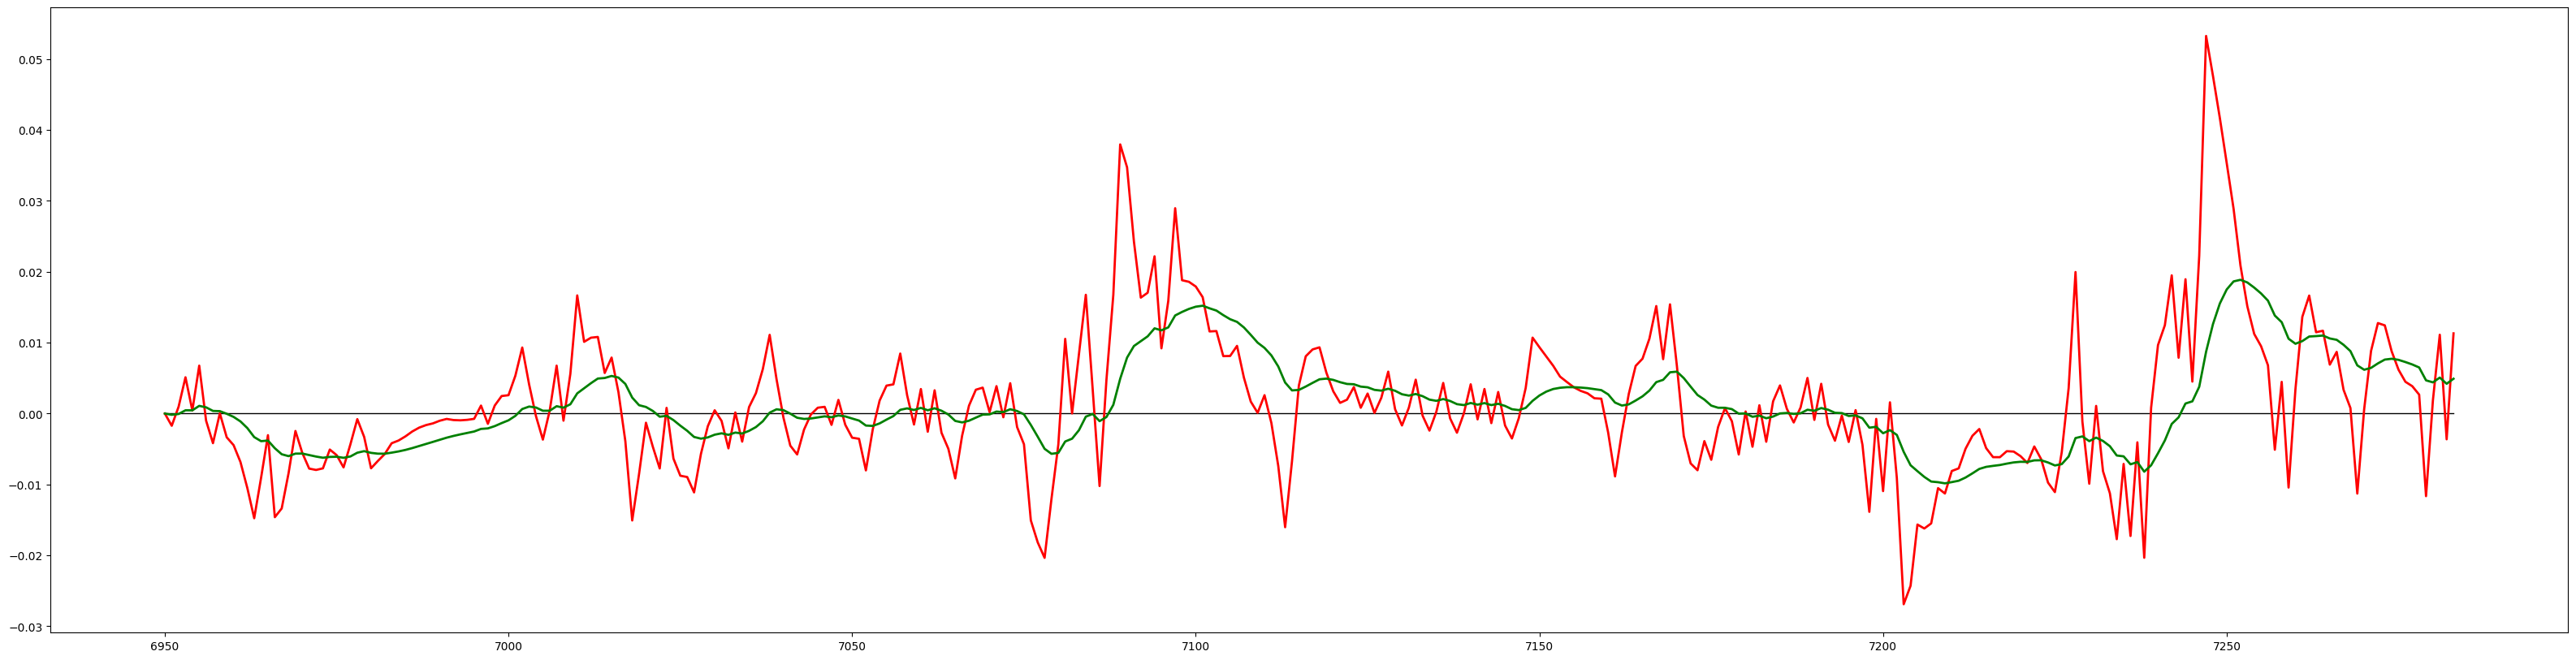

In [6]:
df['smooth_aheadness_dev'] = 0.0
for i in range(len(df)):
    if df.loc[i, 'point_no'] == 1:
        df.loc[i, 'smooth_aheadness_dev'] = 0
    else:
        df.loc[i, 'smooth_aheadness_dev'] = df.loc[i, 'smooth_ahead'] - df.loc[i-1, 'smooth_ahead']


df['aheadness_dev'] = 0.0
for i in range(len(df)):
    if df.loc[i, 'point_no'] == 1:
        df.loc[i, 'aheadness_dev'] = 0
    else:
        df.loc[i, 'aheadness_dev'] = df.loc[i, 'aheadness'] - df.loc[i-1, 'aheadness']

df['simple_exp_smoothed_aheadness_dev'] = 0.0
for i in range(len(df)):
    if df.loc[i, 'point_no'] == 1:
        df.loc[i, 'simple_exp_smoothed_aheadness_dev'] = 0
    else:
        df.loc[i, 'simple_exp_smoothed_aheadness_dev'] = df.loc[i, 'simple_exp_smoothed_aheadness'] - df.loc[i-1, 'simple_exp_smoothed_aheadness']
test_match = df[df['match_id'] == test_match_id]
plt.figure(figsize=(40,10))
plt.plot(np.floor(test_match['p2_break_pt_missed']/2 + 0.01), 'black', lw=1,)
#plt.plot(df[df['match_id'] == '2023-wimbledon-1701']['aheadness_dev'], 'g', lw=2)
plt.plot(test_match['simple_exp_smoothed_aheadness_dev'], 'r', lw=2)

alpha = 0.1
df['exp_smoothed_simple_exp_smoothed_aheadness_dev'] = 0.0
for i in range(len(df)):
    if df.loc[i, 'point_no'] == 1:
        df.loc[i, 'exp_smoothed_simple_exp_smoothed_aheadness_dev'] = df.loc[i, "simple_exp_smoothed_aheadness_dev"]
    else:
        df.loc[i, 'exp_smoothed_simple_exp_smoothed_aheadness_dev'] = alpha*df.loc[i, 'simple_exp_smoothed_aheadness_dev'] + (1 - alpha) * df.loc[i-1, 'exp_smoothed_simple_exp_smoothed_aheadness_dev']
test_match = df[df['match_id'] == test_match_id]
plt.plot(test_match['exp_smoothed_simple_exp_smoothed_aheadness_dev'], 'g', lw=2)

In [7]:
future_points_to_analyze = 4
mom = []
# points_scored = []
# expectations = []
# delta = []
#df["exp_delta"] = 0.0
deriv_type = "exp_smoothed_simple_exp_smoothed_aheadness_dev"
p1_points_scored = []
p1_expectations = []
p1_delta = []
p2_points_scored = []
p2_expectations = []
p2_delta = []

for i in range(len(df)):
    full_analysis = True
    p1_points_won = 0
    p1_expectation = 0
    for j in range(future_points_to_analyze):
        point = i + j
        if point >= len(df) - 1 or df.loc[point, "point_no"] == 1:
            full_analysis = False
            break
        if df.loc[point, "point_victor"] == 1 and df.loc[point, "server"] == 1:
            p1_points_won += 1
            p1_expectation += p
        elif df.loc[point, "point_victor"] == 1 and df.loc[point, "server"] == 2:
            p1_points_won += 1
            p1_expectation += 1 - p
        elif df.loc[point, "point_victor"] == 2 and df.loc[point, "server"] == 1:
            p1_expectation += p
        else:
            p1_expectation += 1 - p
    
    if full_analysis:
        p1_points_scored.append(p1_points_won)
        p1_expectations.append(p1_expectation)
        p1_delta.append(p1_points_won - p1_expectation)
        p2_points_won = future_points_to_analyze - p1_points_won
        p2_expectation = future_points_to_analyze - p1_expectation
        p2_points_scored.append(p2_points_won)
        p2_expectations.append(p2_expectation)
        p2_delta.append(p2_points_won - p2_expectation)
    else:
        p1_delta.append(0)
        p2_delta.append(0)
    
# for i in range(len(df)):
#     momentum = df.loc[i, deriv_type]
#     serving = df.loc[i, "server"]
#     if momentum > 0:
#         points_won = 0
#         expectation = 0
#         full_analysis = True
#         for j in range(future_points_to_analyze):
#             point = i + j
#             if point >= len(df) - 1 or df.loc[point, "point_no"] == 1:
#                 full_analysis = False
#                 break
            # if df.loc[point, "point_victor"] == 1 and df.loc[point, "server"] == 1:
            #     points_won += 1
            #     expectation += p
            # elif df.loc[point, "point_victor"] == 1 and df.loc[point, "server"] == 2:
            #     points_won += 1
            #     expectation += 1 - p
            # elif df.loc[point, "point_victor"] == 2 and df.loc[point, "server"] == 1:
            #     expectation += p
            # else:
#                 expectation += 1 - p
#         if full_analysis:
#             mom.append(abs(momentum))
#             points_scored.append(points_won)
#             expectations.append(expectation)
#             delta.append(points_won - expectation)
#             df.loc[i, "exp_delta"] = points_won - expectation
#         else:
#             df.loc[i, "exp_delta"] = 0
    
#     if momentum < 0:
#         points_won = 0
#         expectation = 0
#         full_analysis = True
#         for j in range(future_points_to_analyze):
#             point = i + j
#             if point >= len(df) - 1 or df.loc[point, "point_no"] == 1:
#                 full_analysis = False
#                 break
#             if df.loc[point, "point_victor"] == 1 and df.loc[point, "server"] == 1:
#                 expectation += 1 - p
#             elif df.loc[point, "point_victor"] == 1 and df.loc[point, "server"] == 2:
#                 expectation += p
#             elif df.loc[point, "point_victor"] == 2 and df.loc[point, "server"] == 1:
#                 points_won += 1
#                 expectation += 1 - p
#             else:
#                 points_won += 1
#                 expectation += p
#         if full_analysis:
#             mom.append(abs(momentum))
#             points_scored.append(points_won)
#             expectations.append(expectation)
#             delta.append(points_won - expectation)
#             df.loc[i, "exp_delta"] = points_won - expectation
#         else:
#             df.loc[i, "exp_delta"] = 0

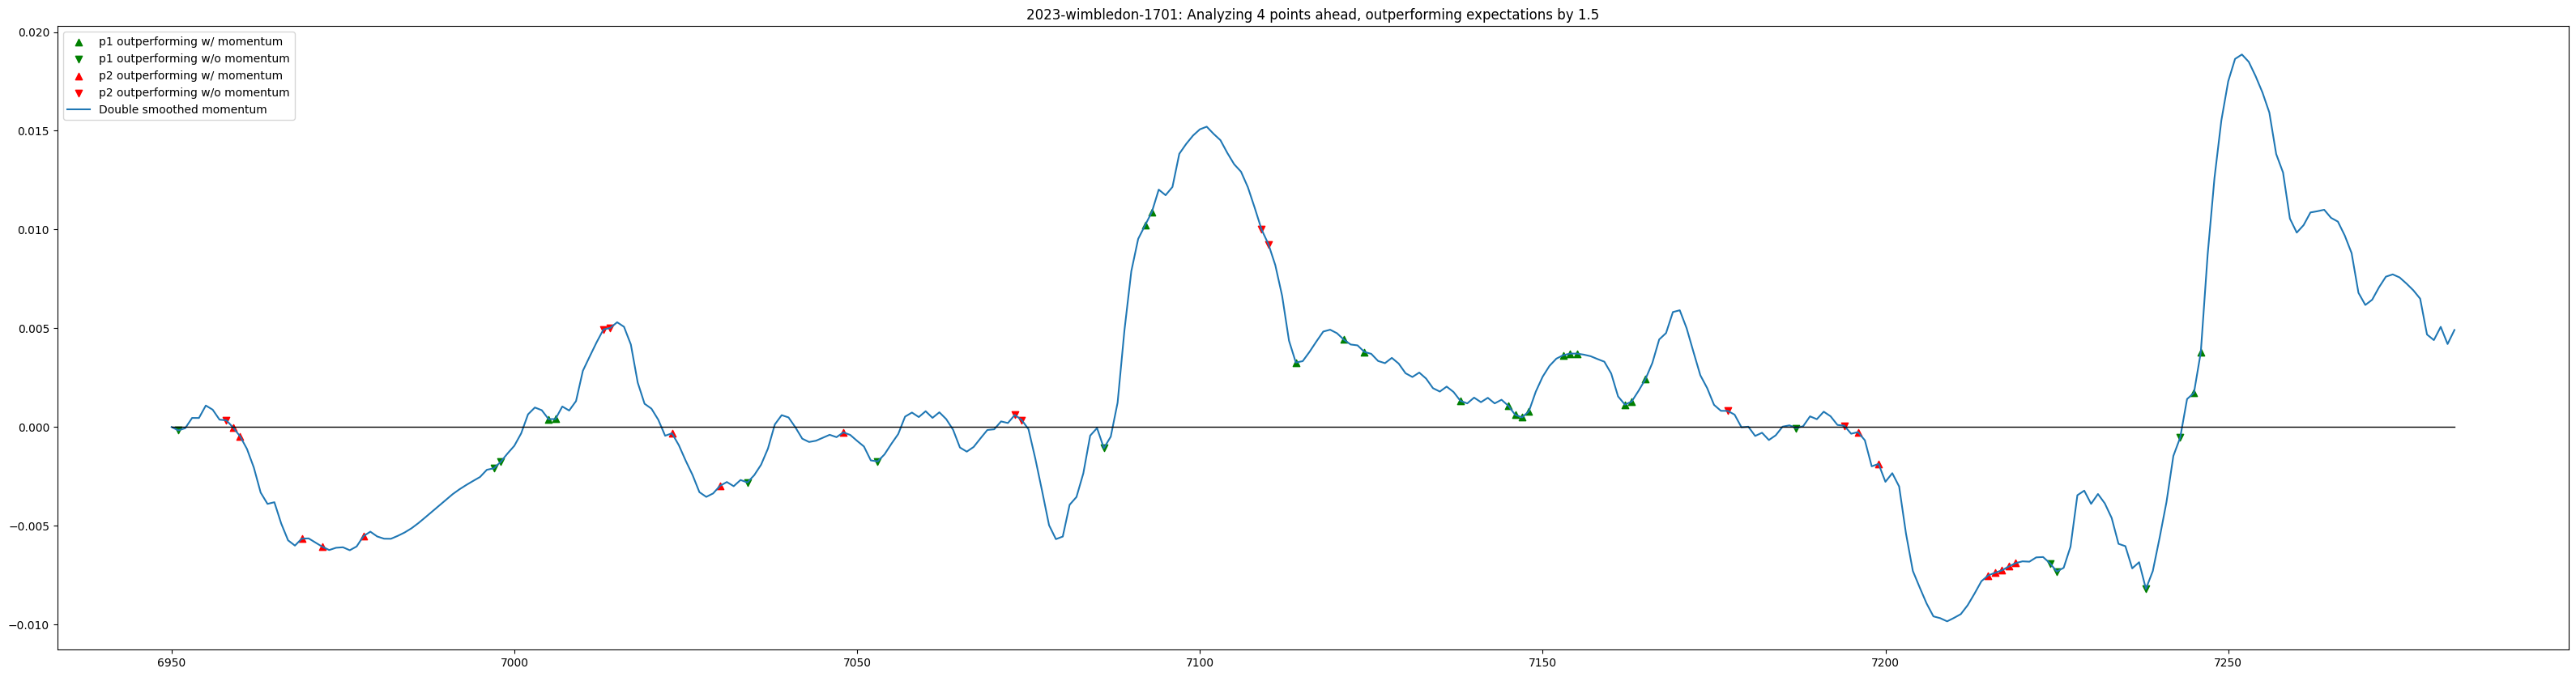

In [8]:

test_match = df[df['match_id'] == test_match_id]
plt.figure(figsize=(40,10))
# p1_indices = []
# big_p1_delta = []
# p2_indices = []
# big_p2_delta = []
p1_outperform_with_momentum = [[], []] # 0 -> indices, 1 -> momentum at index
p1_outperform_without_momentum = [[], []]

p2_outperform_with_momentum = [[], []] # 0 -> indices, 1 -> momentum at index
p2_outperform_without_momentum = [[], []]

first_element = 0
for i in range(len(df)):
    if df.loc[i, "match_id"] == test_match_id and df.loc[i, "point_no"] == 1:
        first_element = i
        break
outperform_val = 1.5
for i in range(first_element, first_element + len(test_match)):
    if p1_delta[i] > outperform_val and test_match.loc[i, deriv_type] > 0: # p1 outperforms with momentum
        p1_outperform_with_momentum[0].append(i)
        p1_outperform_with_momentum[1].append(test_match.loc[i, deriv_type])
    
    if p1_delta[i] > outperform_val and test_match.loc[i, deriv_type] < 0: # p1 outperforms without momentum
        p1_outperform_without_momentum[0].append(i)
        p1_outperform_without_momentum[1].append(test_match.loc[i, deriv_type])

    if p2_delta[i] > outperform_val and test_match.loc[i, deriv_type] < 0: # p2 outperforms with momentum
        p2_outperform_with_momentum[0].append(i)
        p2_outperform_with_momentum[1].append(test_match.loc[i, deriv_type])
    
    if p2_delta[i] > outperform_val and test_match.loc[i, deriv_type] > 0: # p2 outperforms without momentum
        p2_outperform_without_momentum[0].append(i)
        p2_outperform_without_momentum[1].append(test_match.loc[i, deriv_type])

    # if test_match.loc[i, "exp_delta"] > outperform_val and test_match.loc[i, deriv_type] > 0:
    #     p1_indices.append(i)
    #     big_p1_delta.append(test_match.loc[i, deriv_type])
    # if test_match.loc[i, "exp_delta"] > outperform_val and test_match.loc[i, deriv_type] < 0:
    #     p2_indices.append(i)
    #     big_p2_delta.append(test_match.loc[i, deriv_type])


plt.scatter(p1_outperform_with_momentum[0], p1_outperform_with_momentum[1], c = 'green', marker="^", label = "p1 outperforming w/ momentum")
plt.scatter(p1_outperform_without_momentum[0], p1_outperform_without_momentum[1], c = 'green', marker="v", label = "p1 outperforming w/o momentum")
plt.scatter(p2_outperform_with_momentum[0], p2_outperform_with_momentum[1], c = 'red', marker="^", label = "p2 outperforming w/ momentum")
plt.scatter(p2_outperform_without_momentum[0], p2_outperform_without_momentum[1], c = 'red', marker="v", label = "p2 outperforming w/o momentum")
plt.plot(test_match[deriv_type], label="Double smoothed momentum")
plt.legend(loc="upper left")
plt.plot(np.floor(test_match['p2_break_pt_missed']/2 + 0.01), 'black', lw=1,)
plt.title(test_match_id + ": Analyzing " + str(future_points_to_analyze) + " points ahead, outperforming expectations by " + str(outperform_val))
plt.show()

In [9]:
print(len(p1_outperform_with_momentum[0]), len(p1_outperform_without_momentum[0]))
print(len(p2_outperform_with_momentum[0]), len(p1_outperform_without_momentum[0]))

20 11
15 11


In [10]:
rounds = {"3": [0,0],
         "4": [0,0],
         "5": [0,0],
         "6": [0,0],
         "7": [0,0]}

for id in list(set(df["match_id"])):
    p1_outperform_with_momentum = [[], []] # 0 -> indices, 1 -> momentum at index
    p1_outperform_without_momentum = [[], []]

    p2_outperform_with_momentum = [[], []] # 0 -> indices, 1 -> momentum at index
    p2_outperform_without_momentum = [[], []]
    rnd = id.split("-")[2][1]
    first_element = 0
    for i in range(len(df)):
        if df.loc[i, "match_id"] == id and df.loc[i, "point_no"] == 1:
            first_element = i
            break
    outperform_val = 1.5
    test_match = df[df['match_id'] == id]
    for i in range(first_element, first_element + len(test_match)):
        if p1_delta[i] > outperform_val and test_match.loc[i, deriv_type] > 0: # p1 outperforms with momentum
            p1_outperform_with_momentum[0].append(i)
            p1_outperform_with_momentum[1].append(test_match.loc[i, deriv_type])
        
        if p1_delta[i] > outperform_val and test_match.loc[i, deriv_type] < 0: # p1 outperforms without momentum
            p1_outperform_without_momentum[0].append(i)
            p1_outperform_without_momentum[1].append(test_match.loc[i, deriv_type])

        if p2_delta[i] > outperform_val and test_match.loc[i, deriv_type] < 0: # p2 outperforms with momentum
            p2_outperform_with_momentum[0].append(i)
            p2_outperform_with_momentum[1].append(test_match.loc[i, deriv_type])
        
        if p2_delta[i] > outperform_val and test_match.loc[i, deriv_type] > 0: # p2 outperforms without momentum
            p2_outperform_without_momentum[0].append(i)
            p2_outperform_without_momentum[1].append(test_match.loc[i, deriv_type])
    
    rounds[rnd][0] += len(p1_outperform_with_momentum[0]) + len(p2_outperform_with_momentum[0])
    rounds[rnd][1] += len(p1_outperform_without_momentum[0]) + len(p2_outperform_without_momentum[0])

for k in rounds.keys():
    print("Round " + k + ": Outperform with momentum/outperform without momentum = " + str(round(rounds[k][0]/rounds[k][1], 4)))

Round 3: Outperform with momentum/outperform without momentum = 1.1462
Round 4: Outperform with momentum/outperform without momentum = 1.4356
Round 5: Outperform with momentum/outperform without momentum = 2.122
Round 6: Outperform with momentum/outperform without momentum = 1.6316
Round 7: Outperform with momentum/outperform without momentum = 1.75


In [173]:
# prediction model for part c
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score
from sklearn.utils import class_weight
from xgboost import XGBClassifier
from sklearn.inspection import permutation_importance

def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn

for match_id in df['match_id'].unique():
    match_data = df[df['match_id'] == match_id]
    Y = []
    for i in range(len(match_data)-1):
        if (match_data.iloc[i]["exp_smoothed_simple_exp_smoothed_aheadness_dev"] < 0) and (match_data.iloc[i+1]["exp_smoothed_simple_exp_smoothed_aheadness_dev"] > 0):
            Y.append(1)
        elif (match_data.iloc[i]["exp_smoothed_simple_exp_smoothed_aheadness_dev"] > 0) and (match_data.iloc[i+1]["exp_smoothed_simple_exp_smoothed_aheadness_dev"] < 0):
            Y.append(-1)
        else:
            Y.append(0)
    Y.append(0)
    Y = pd.Series(Y)

    model = LogisticRegression(multi_class='multinomial', class_weight='balanced', random_state=0)
    #model = XGBClassifier(random_state=0, objective='multi:softmax', enable_categorical=True)
    X = match_data[[
        'p1_ace', 'p2_ace', 'p1_winner', 'p2_winner', 'p1_double_fault', 'p2_double_fault', 'p1_break_pt_won', 'p2_break_pt_won',
        'p1_break_pt_missed', 'p2_break_pt_missed', 'p1_distance_run', 'p2_distance_run', 'rally_count', 'aheadness', 'exp_smoothed_simple_exp_smoothed_aheadness_dev',
    ]]

    # cats = ['p1_ace', 'p2_ace', 'p1_winner', 'p2_winner', 'p1_double_fault', 'p2_double_fault', 'p1_break_pt_won', 'p2_break_pt_won',
    #     'p1_break_pt_missed', 'p2_break_pt_missed','serve_depth', 'return_depth','serve_width']
    # for col in cats:
    #     X[col] = X[col].astype('category')

    Y = Y.apply(lambda x: x+1)
    model.fit(X, Y)
    print(f'\033[92m{match_id}: {f1_score(Y, model.predict(X), average=None)}, {precision_score(Y, model.predict(X), average=None)}\033[0m')
    print(model.coef_)
    #print(accuracy_score(Y, model.predict(X)))

2023-wimbledon-1301: [0.12345679 0.6572104  0.1875    ], [0.06849315 0.99285714 0.10344828]
[[-0.62666321 -0.10720831 -1.18665976  1.71317596 -0.42688555 -1.14450165
  -0.23503956  2.07964012 -0.7695004  -0.23329145  0.0099013  -0.03368419
  -0.05874163 -0.306602   -0.00966077]
 [-0.96236835  0.51610344  1.54912147  0.4850332   0.7840282  -0.77276151
   0.54488964 -1.00741649  1.0799079   0.55254763 -0.00602391  0.00763705
   0.01451693  2.16262087  0.03533164]
 [ 1.58903156 -0.40889512 -0.3624617  -2.19820916 -0.35714265  1.91726316
  -0.30985008 -1.07222363 -0.3104075  -0.31925618 -0.00387739  0.02604714
   0.0442247  -1.85601887 -0.02567087]]
2023-wimbledon-1302: [0.14285714 0.60363636 0.14035088], [0.08064516 0.93258427 0.08      ]
[[-0.51346523  0.09422734 -2.1014607   0.34964541 -0.03337125 -0.08211332
   0.         -0.06556261 -0.0480227  -0.15089169 -0.09510811 -0.14158446
   0.96962574  0.75353238  0.0217318 ]
 [ 0.27943072  0.25470948  0.35429797  0.79585117  0.08742822  0.24

In [313]:
len(df[df['match_id'].isin(train_ids)])
#len(df[~df['match_id'].isin(train_ids)])

5707

In [307]:
# fit on rounds 3 and 4, test on 5,6,7
from scipy.stats import hmean
# FIND A SPLIT THAT WORKS BETTER THAN OTHERS
dfs = df[(df['set_no'] > 1)]
print(len(dfs))

train_ids = [x for x in dfs['match_id'].unique() if '-13' in x or '-14' in x]
train = dfs[dfs['match_id'].isin(train_ids)]
test = dfs[~dfs['match_id'].isin(train_ids)]

train_Y = []
for i in range(len(train)-1):
    if train.iloc[i]['match_id'] == train.iloc[i+1]['match_id']:
        if (train.iloc[i]["exp_smoothed_simple_exp_smoothed_aheadness_dev"] < 0) and (train.iloc[i+1]["exp_smoothed_simple_exp_smoothed_aheadness_dev"] > 0):
            train_Y.append(1)
        elif (train.iloc[i]["exp_smoothed_simple_exp_smoothed_aheadness_dev"] > 0) and (train.iloc[i+1]["exp_smoothed_simple_exp_smoothed_aheadness_dev"] < 0):
            train_Y.append(-1)
        else:
            train_Y.append(0)
    else:
        train_Y.append(0)
train_Y.append(0)
train_Y = pd.Series(train_Y)

test_Y = []
for i in range(len(test)-1):
    if test.iloc[i]['match_id'] == test.iloc[i+1]['match_id']:
        if (test.iloc[i]["exp_smoothed_simple_exp_smoothed_aheadness_dev"] < 0) and (test.iloc[i+1]["exp_smoothed_simple_exp_smoothed_aheadness_dev"] > 0):
            test_Y.append(1)
        elif (test.iloc[i]["exp_smoothed_simple_exp_smoothed_aheadness_dev"] > 0) and (test.iloc[i+1]["exp_smoothed_simple_exp_smoothed_aheadness_dev"] < 0):
            test_Y.append(-1)
        else:
            test_Y.append(0)
    else:
        test_Y.append(0)
test_Y.append(0)
test_Y = pd.Series(test_Y)

train_X = train[[
        'p1_ace', 'p2_ace', 'p1_winner', 'p2_winner', 'p1_double_fault', 'p2_double_fault', 'p1_break_pt_won', 'p2_break_pt_won',
        'p1_break_pt_missed', 'p2_break_pt_missed', 'p1_distance_run', 'p2_distance_run', 'rally_count', 'exp_smoothed_simple_exp_smoothed_aheadness_dev',
        'serve_depth', 'return_depth', 'speed_mph', 'serve_width'
    ]]

test_X = test[[
        'p1_ace', 'p2_ace', 'p1_winner', 'p2_winner', 'p1_double_fault', 'p2_double_fault', 'p1_break_pt_won', 'p2_break_pt_won',
        'p1_break_pt_missed', 'p2_break_pt_missed', 'p1_distance_run', 'p2_distance_run', 'rally_count', 'exp_smoothed_simple_exp_smoothed_aheadness_dev',
        'serve_depth', 'return_depth', 'speed_mph', 'serve_width'
    ]]

classes_weights = class_weight.compute_sample_weight(
    class_weight='balanced',
    y=train_Y
) * 100

cols = [
        'p1_ace', 'p2_ace', 'p1_winner', 'p2_winner', 'p1_double_fault', 'p2_double_fault', 'p1_break_pt_won', 'p2_break_pt_won',
        'p1_break_pt_missed', 'p2_break_pt_missed', 'p1_distance_run', 'p2_distance_run', 'rally_count', 'exp_smoothed_simple_exp_smoothed_aheadness_dev',
        'serve_depth', 'return_depth', 'speed_mph', 'serve_width'
    ]

cats = [c for c in ['p1_ace', 'p2_ace', 'p1_winner', 'p2_winner', 'p1_double_fault', 'p2_double_fault', 'p1_break_pt_won', 'p2_break_pt_won',
            'p1_break_pt_missed', 'p2_break_pt_missed','serve_depth', 'return_depth','serve_width']]# if c != col]

#model = LogisticRegression(multi_class='multinomial', class_weight='balanced')
#model = RandomForestClassifier(class_weight='balanced')
model = HistGradientBoostingClassifier(categorical_features=cats, random_state=42)
train_Y = train_Y.apply(lambda x: x+1)
test_Y = test_Y.apply(lambda x: x+1)

#model = XGBClassifier(random_state=0, objective='multi:softmax', enable_categorical=True)
model.fit(train_X, train_Y, sample_weight=classes_weights)

# print(recall_score(test_Y, model.predict(test_X), average=None))
# print(precision_score(test_Y, model.predict(test_X), average=None))

# importances = permutation_importance(model, train_X, train_Y, n_repeats=10, random_state=0, n_jobs=-1)
# print(importances.importances_mean)

print()
test['test_Y'] = np.array(test_Y)
for name, group in test.groupby('match_id'):
    print(f"{name}: {f1_score(group['test_Y'], model.predict(group.drop('test_Y', axis=1)), average=None)}")

5357

2023-wimbledon-1501: [0.         0.98522167]
2023-wimbledon-1502: [0.71428571 0.98305085 0.72727273]
2023-wimbledon-1503: [0.66666667 0.98550725 0.        ]
2023-wimbledon-1504: [0.         0.96989967 0.28571429]
2023-wimbledon-1601: [0.33333333 0.97560976 0.66666667]
2023-wimbledon-1602: [0.53333333 0.95202952 0.4       ]
2023-wimbledon-1701: [0.5        0.9725777  0.53333333]


In [ ]:
one_hot = pd.get_dummies(pd.concat((train_X, test_X))[cats])
df2 = pd.concat((train_X, test_X)).drop(cats, axis=1)
df2 = df2.join(one_hot).drop('exp_smoothed_simple_exp_smoothed_aheadness_dev', axis=1)
plt.figure(figsize=(5,20))
sns.heatmap(pd.DataFrame(df2.corrwith(pd.concat((train_Y, test_Y)))), vmin=-.1, vmax=.1, cmap='vlag')

0.6731191652937946
3: 0.6663146779303062
4: 0.6993225638353309
5: 0.6780045351473923
6: 0.6509695290858726
7: 0.6107784431137725


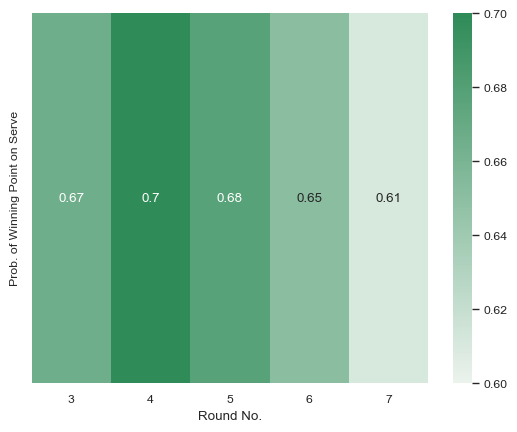

In [291]:
# value of p = (times p1 served and won point + times p2 served and won point) / total rows
hits = 0
for i, row in df.iterrows():
    hits += row['server'] == row['point_victor']
print(hits / len(df))

df['round'] = df['match_id'].apply(lambda s: s[-3])
pbyround = pd.DataFrame()
rounds = []
pvals = []
for name, group in df.groupby('round'):
    hits = 0
    for i, row in group.iterrows():
        hits += row['server'] == row['point_victor']
    print(f'{name}: {hits/len(group)}')
    rounds.append(int(name))
    pvals.append(hits/len(group))
pbyround.index = rounds
pbyround['Prob. of Winning Point on Serve'] = pvals
green = sns.light_palette("seagreen", as_cmap=True)
ax = sns.heatmap(pbyround.T, vmin=.6, vmax=.7, cmap=green, annot=True)
ax.set_xlabel('Round No.')
plt.savefig('serve_probs.png')